In [9]:
!pip install mlxtend
!pip install networkx

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Groceries_dataset.csv to Groceries_dataset (1).csv


In [12]:
df = pd.read_csv('Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [13]:
# Combine transactions into basket format
basket = df.groupby(['Member_number', 'itemDescription'])['itemDescription'] \
            .count().unstack().fillna(0)

# Convert to binary (0/1)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

frequent_itemsets.sort_values('support', ascending=False).head(10)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules = rules.sort_values('lift', ascending=False)
rules.head()
strong_rules = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.2)
]

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2738,"(bottled water, yogurt)","(whole milk, other vegetables)",0.066444,0.191380,0.022063,0.332046,1.735009,1.0,0.009346,1.210593,0.453786,0.093580,0.173958,0.223664
2936,"(sausage, yogurt)","(rolls/buns, whole milk)",0.075423,0.178553,0.022832,0.302721,1.695412,1.0,0.009365,1.178075,0.443633,0.098779,0.151158,0.215297
2930,"(rolls/buns, whole milk, yogurt)",(sausage),0.065931,0.206003,0.022832,0.346304,1.681060,1.0,0.009250,1.214626,0.433734,0.091658,0.176701,0.228569
2778,"(rolls/buns, sausage)","(whole milk, other vegetables)",0.082350,0.191380,0.026167,0.317757,1.660344,1.0,0.010407,1.185237,0.433406,0.105699,0.156287,0.227243
2928,"(rolls/buns, sausage, whole milk)",(yogurt),0.048743,0.282966,0.022832,0.468421,1.655399,1.0,0.009040,1.348877,0.416203,0.073920,0.258642,0.274555
2872,"(sausage, whole milk, other vegetables)",(yogurt),0.050282,0.282966,0.023089,0.459184,1.622754,1.0,0.008861,1.325837,0.404082,0.074442,0.245760,0.270390
2850,"(rolls/buns, yogurt)","(whole milk, other vegetables)",0.111339,0.191380,0.034377,0.308756,1.613311,1.0,0.013068,1.169803,0.427786,0.128107,0.145155,0.244190
2878,"(sausage, yogurt)","(whole milk, other vegetables)",0.075423,0.191380,0.023089,0.306122,1.599551,1.0,0.008654,1.165364,0.405401,0.094737,0.141899,0.213383
2793,"(rolls/buns, shopping bags)","(whole milk, other vegetables)",0.068753,0.191380,0.021036,0.305970,1.598756,1.0,0.007878,1.165108,0.402164,0.087983,0.141711,0.207945
2916,"(rolls/buns, soda, whole milk)",(sausage),0.065162,0.206003,0.021036,0.322835,1.567135,1.0,0.007613,1.172530,0.387118,0.084103,0.147144,0.212476


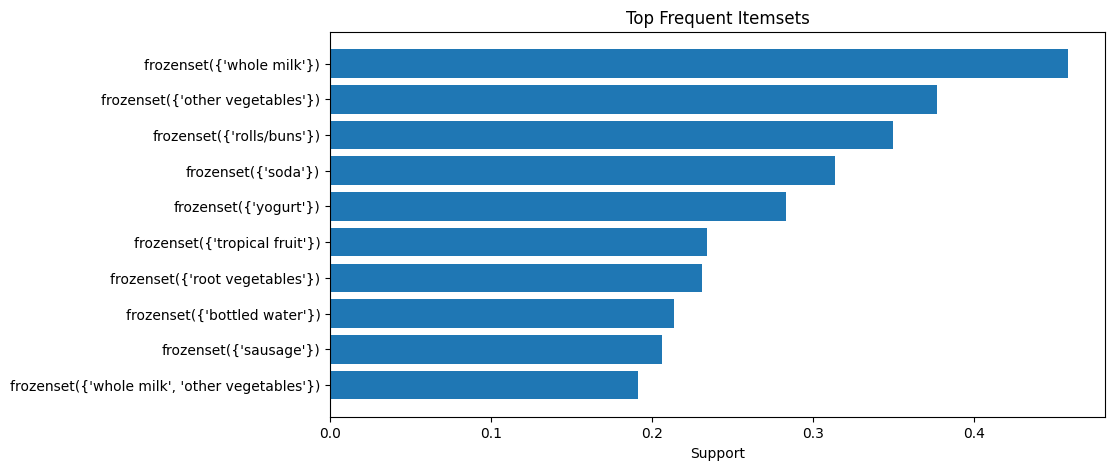

In [14]:
top_items = frequent_itemsets.sort_values('support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_items['itemsets'].astype(str),
    top_items['support']
)
plt.xlabel("Support")
plt.title("Top Frequent Itemsets")
plt.gca().invert_yaxis()
plt.show()

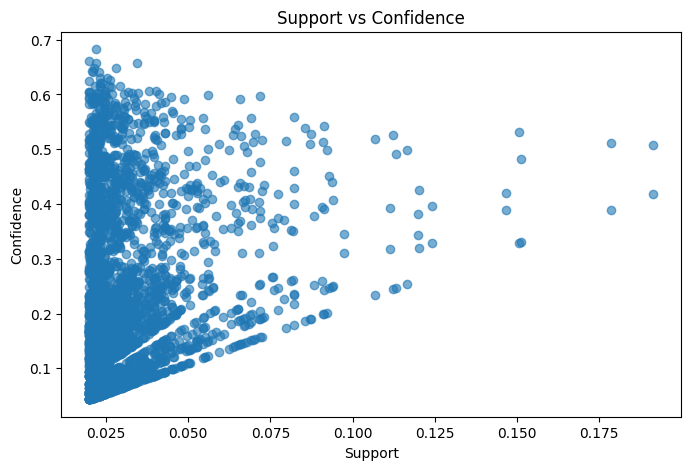

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(rules['support'], rules['confidence'], alpha=0.6)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

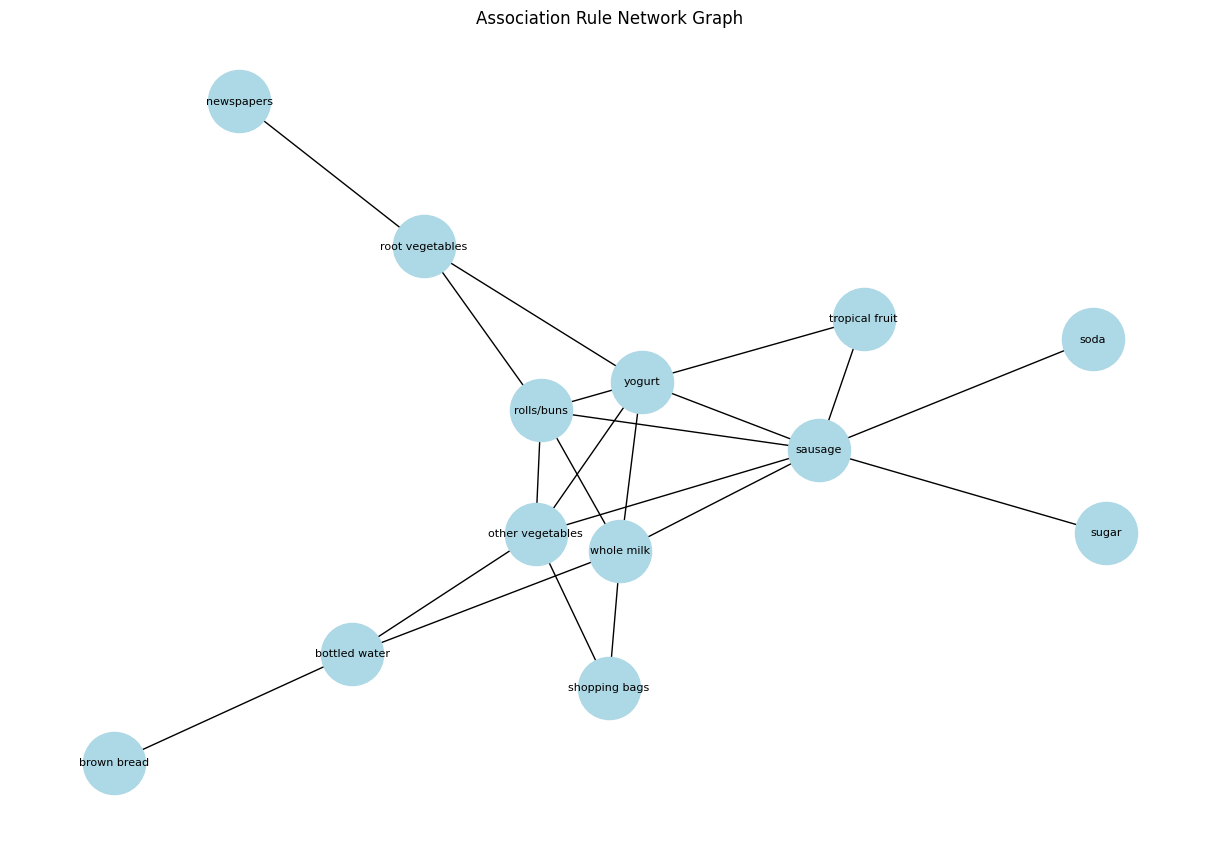

In [16]:
G = nx.Graph()

for _, row in strong_rules.head(20).iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.8)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=8)
plt.title("Association Rule Network Graph")
plt.show()


Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]


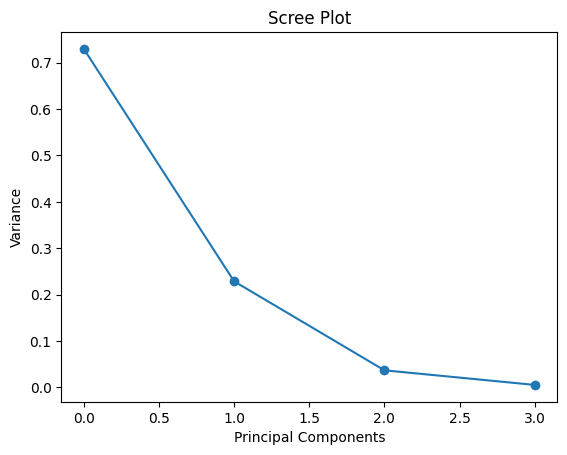

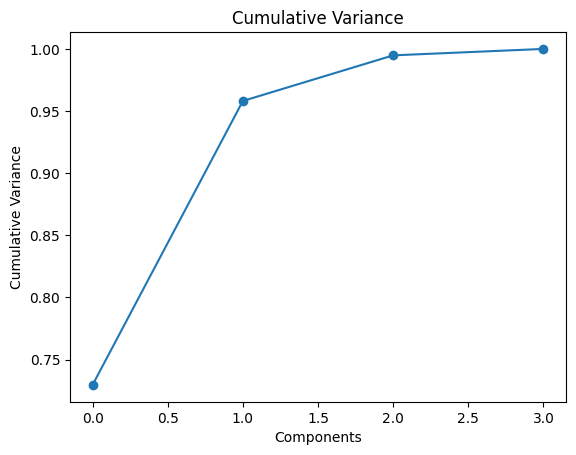

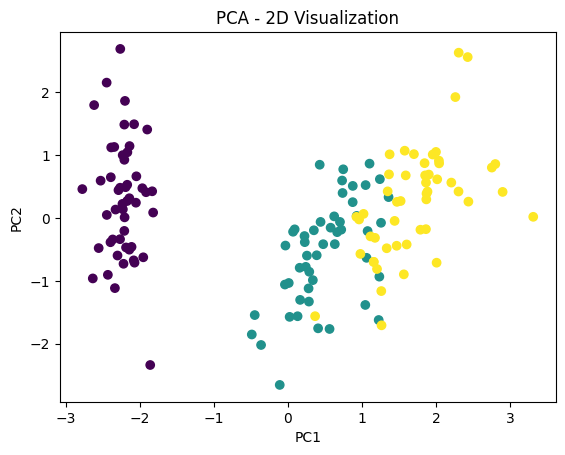

In [17]:
# Roll No: 24BAD077
# Name: Navithanjali M S

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

data = load_iris()
X = data.data
y = data.target

# -------------------------------
# Step 2: Standardization
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 3: Apply PCA
# -------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# Step 4: Explained Variance
# -------------------------------

print("\nExplained Variance Ratio:\n", pca.explained_variance_ratio_)

# -------------------------------
# Step 5: Scree Plot
# -------------------------------

plt.figure()
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

# -------------------------------
# Step 6: Cumulative Variance
# -------------------------------

cum_var = pca.explained_variance_ratio_.cumsum()
plt.figure()
plt.plot(cum_var, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

# -------------------------------
# Step 7: Reduce to 2D
# -------------------------------

pca2 = PCA(n_components=2)
X_reduced = pca2.fit_transform(X_scaled)

# -------------------------------
# Step 8: 2D Scatter Plot
# -------------------------------

plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Visualization")
plt.show()